# DMRs vs ATAC-seq peaks (Fig 2N, S13, S14A)

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}scATAC/celltypes.txt.gz'`  ·  _scATAC peaks_
- `f'{indir}scATAC/peak/peaklist.txt'`  ·  _scATAC peaks_
- `f'{indir}scATAC/cCREs.bed.gz'`  ·  _scATAC peaks_
- `f'{indir}scATAC/atac2majortype.tsv'`  ·  _scATAC peaks_
- `f'{out_dir}top200k_atac_count.txt'`  ·  _ATAC_
- `f'{out_dir}top200k_dmr_count.txt'`  ·  _DMR_
- `f'{out_dir}dms{ndms}_atac_count.txt'`  ·  _ATAC_
- `f'{out_dir}dms{ndms}_dmr_count.txt'`  ·  _DMR_
- `f'{out_dir}/dms{ndms}_atac_count.txt'`  ·  _ATAC_
- `f'{out_dir}/dms{ndms}_dmr_count.txt'`  ·  _DMR_
- `f'{out_dir}/top200k_atac_count.txt'`  ·  _ATAC_
- `f'{out_dir}/top200k_dmr_count.txt'`  ·  _DMR_
- `f'{out_dir}/dms{ndms}_merged_atac_count_new.txt'`  ·  _ATAC_
- `f'{out_dir}/dms{ndms}_merged_dmr_count_new.txt'`  ·  _DMR_
- `f'{out_dir}/dms{ndms}_merged_atac_count.txt'`  ·  _ATAC_
- `f'{out_dir}/dms{ndms}_merged_dmr_count.txt'`  ·  _DMR_
- `f'{peak_dir}cCREs_distal2k_104celltype.npz'`  ·  _other_
- `f'{outdir}flank_bed/cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf'`  ·  _other_
- `f'{outdir}overlap_atac/atac_count.txt'`  ·  _ATAC_
- `f'{outdir}overlap_atac/dmr_count.txt'`  ·  _DMR_
- `f'{outdir}overlap_atac/majortype_36groups/subtype_dmr.mcds'`  ·  _mC matrix (mcds)_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{outdir}overlap_atac/majortype_36groups/L1_merged_dmr.hdf'`  ·  _DMR_
- `f'{outdir}overlap_atac/majortype_36groups/merged_dmr_nonpeak.bed'`  ·  _DMR_
- `f'{outdir}overlap_atac/majortype_36groups/merged_dmr_peak.bed'`  ·  _DMR_
- `f'{indir}DMR/majortype-subtype/{ct}_dmr'`  ·  _DMR_
- `f'{indir}DMR/majortype-subtype/{mt}_dmr'`  ·  _DMR_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import anndata
from ALLCools.mcds import MCDS, RegionDS
from ALLCools.clustering import *
from ALLCools.plot import *

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/DMR/'


In [4]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [5]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


## majortype DMR

In [6]:
## write majortype hypo DMR with >=2 DMS

ndms = 2
for ngroup in [29, 33, 34, 35, 36]:
    dmr_dir = f'{indir}DMR/majortype/{ngroup}groups'
    out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'
    dmr_ds = RegionDS.open(dmr_dir, region_dim='dmr')
    dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
    dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
    seldmr = (dmr['dmr_ndms']>=ndms) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
    dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
    dmr = dmr.loc[seldmr]
    dmr_state = dmr_ds['dmr_state'].to_pandas().T
    dmr_data = dmr_ds['dmr_da_frac'].to_pandas().T.fillna(1)
    if 'c36' not in dmr_state.columns:
        dmr_state = dmr_state.rename({'c7':'c35', 'c35':'c36'}, axis=1)
        dmr_data = dmr_data.rename({'c7':'c35', 'c35':'c36'}, axis=1)

    for ct in dmr_state.columns:
        dmr_tmp = dmr.loc[dmr_state[ct]==-1]
        dmr_tmp['mCG'] = dmr_data[ct].copy()
        dmr_tmp = dmr_tmp.reset_index()[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr', 'dmr_ndms', 'mCG']]
        dmr_tmp.sort_values(by=['dmr_chrom', 'dmr_start']).to_csv(f'{dmr_dir}/hypo/{ct}_hypo.bed', 
                                                                  sep='\t', header=False, index=False)


In [7]:
## write majortype atac peaks

import scipy.io as sio

peak_matrix = sio.mmread(f'{indir}scATAC/matrix.tsv.gz')
atac_ct_list = pd.read_csv(f'{indir}scATAC/celltypes.txt.gz', index_col=0, header=None).index
selct = pd.read_csv(f'{indir}scATAC/peak/peaklist.txt', sep='.', index_col=0, header=None).index
selct = atac_ct_list[atac_ct_list.isin(selct)]
print(selct.shape[0])

peak = pd.read_csv(f'{indir}scATAC/cCREs.bed.gz', sep='\t', names=['chrom','start','end'], 
                   header=None, index_col=None)
peak_matrix = peak_matrix.tocsr()[:, atac_ct_list.isin(selct)]
selp = peak['chrom'].isin(chrom_sizes.index) & (peak_matrix.getnnz(axis=1)>0)
peak = peak.loc[selp]
peak_matrix = peak_matrix[selp]

atac2mt = pd.read_csv(f'{indir}scATAC/atac2majortype.tsv', sep='\t', header=None, index_col=None)
atac2mt = atac2mt.loc[~atac2mt[1].isna()]
mt2atac = {xx:[] for xx in L1_meta['L1_abbr']}
for xx,yy in atac2mt.values:
    for y in yy.split(','):
        mt2atac[y].append(xx)

selct = pd.Series(np.arange(len(selct)), index=selct)
ctcre = {}
for ct in L1_meta.index:
    ctname = L1_annot[ct]
    if len(mt2atac[ctname])>0:
        selp = peak_matrix[:, selct.loc[mt2atac[ctname]]].getnnz(axis=1)>0
        peak.loc[selp].sort_values(['chrom', 'start']).to_csv(f'{indir}scATAC/peak/majortype/{ct}.bed', 
                              header=False, index=False, sep='\t')


In [8]:
## proportion overlap for different ngroup and ndms, all cell types

for ngroup in [29,33,34,35,36]:
    out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'

    data1 = pd.read_csv(f'{out_dir}top200k_atac_count.txt', sep=' ', header=None, index_col=0)
    data1 = data1.loc[L1_meta.index]
    data1 = data1.loc[data1[1]>0]

    data2 = pd.read_csv(f'{out_dir}top200k_dmr_count.txt', sep=' ', header=None, index_col=0)
    data2 = data2.loc[L1_meta.index]
    data2 = data2.loc[data2[1]>0]

    print(ngroup, '200k', pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1).mean(axis=0).mean())

    for ndms in [2,3,4,5]:
        data1 = pd.read_csv(f'{out_dir}dms{ndms}_atac_count.txt', sep=' ', header=None, index_col=0)
        data1 = data1.loc[L1_meta.index]
        data1 = data1.loc[data1[1]>0]

        data2 = pd.read_csv(f'{out_dir}dms{ndms}_dmr_count.txt', sep=' ', header=None, index_col=0)
        data2 = data2.loc[L1_meta.index]
        data2 = data2.loc[data2[1]>0]

        print(ngroup, ndms, pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1).mean(axis=0).mean())


In [9]:
## select 29 celltypes

ndms = 2
ngroup = 29
out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'
data1 = pd.read_csv(f'{out_dir}dms{ndms}_atac_count.txt', sep=' ', header=None, index_col=0)
data1 = data1.loc[L1_meta.index]
data1 = data1.loc[data1[1]>0]

data2 = pd.read_csv(f'{out_dir}dms{ndms}_dmr_count.txt', sep=' ', header=None, index_col=0)
data2 = data2.loc[L1_meta.index]
data2 = data2.loc[data2[1]>0]

selct = data2.index

In [10]:
## proportion overlap for different ngroup and ndms, 29 cell types

for ngroup in [29,33,34,35,36]:
    out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'

    data1 = pd.read_csv(f'{out_dir}top200k_atac_count.txt', sep=' ', header=None, index_col=0)
    data1 = data1.loc[L1_meta.index]
    data1 = data1.loc[data1[1]>0]

    data2 = pd.read_csv(f'{out_dir}top200k_dmr_count.txt', sep=' ', header=None, index_col=0)
    data2 = data2.loc[L1_meta.index]
    data2 = data2.loc[data2[1]>0]
    tmp = pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1)
    print(ngroup, '200k', tmp.loc[selct].mean(axis=0).values, np.nanmean(tmp.loc[selct].values))

    for ndms in [2,3,4,5]:
        data1 = pd.read_csv(f'{out_dir}dms{ndms}_atac_count.txt', sep=' ', header=None, index_col=0)
        data1 = data1.loc[L1_meta.index]
        data1 = data1.loc[data1[1]>0]

        data2 = pd.read_csv(f'{out_dir}dms{ndms}_dmr_count.txt', sep=' ', header=None, index_col=0)
        data2 = data2.loc[L1_meta.index]
        data2 = data2.loc[data2[1]>0]
        tmp = pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1)
        print(ngroup, ndms, tmp.loc[selct].mean(axis=0).values, np.nanmean(tmp.loc[selct].values))


In [11]:
ndms = 2
ngroup = 36
out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'
data1 = pd.read_csv(f'{out_dir}/dms{ndms}_atac_count.txt', sep=' ', header=None, index_col=0)
data1 = data1.loc[L1_meta.index]
data1 = data1.loc[data1[1]>0]

data2 = pd.read_csv(f'{out_dir}/dms{ndms}_dmr_count.txt', sep=' ', header=None, index_col=0)
data2 = data2.loc[L1_meta.index]
data2 = data2.loc[data2[1]>0]

print(pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1).mean(axis=0))

# colors = sns.color_palette('tab20', 4)
colors = list(list(sns.color_palette('Greens_r', 2) + sns.color_palette('Blues_r', 2)))

In [12]:
ngroup = 36
out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'
data1 = pd.read_csv(f'{out_dir}/top200k_atac_count.txt', sep=' ', header=None, index_col=0)
data1 = data1.loc[L1_meta.index]
data1 = data1.loc[data1[1]>0]

data2 = pd.read_csv(f'{out_dir}/top200k_dmr_count.txt', sep=' ', header=None, index_col=0)
data2 = data2.loc[L1_meta.index]
data2 = data2.loc[data2[1]>0]

print(pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1).mean(axis=0))

# colors = sns.color_palette('tab20', 4)
colors = list(list(sns.color_palette('Greens_r', 2) + sns.color_palette('Blues_r', 2)))

## majortype-subtype DMR

In [13]:
## write majortype-subtype DMR with >=2 DMS

ndms = 2
for ct in L1_meta.index:
    dmr_dir = f'{indir}DMR/majortype-subtype/{ct}_dmr'
    if not os.path.exists(f'{dmr_dir}/dmr.bed'):
        continue
    dmr_ds = RegionDS.open(dmr_dir, region_dim='dmr')
    dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
    dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
    seldmr = (dmr['dmr_ndms']>=ndms) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
    dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
    dmr = dmr.loc[seldmr]
    dmr_data = dmr_ds['dmr_da_frac'].to_pandas().T.fillna(1)
    dmr['mCG'] = dmr_data.min(axis=1)
    dmr = dmr.reset_index()[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr', 'dmr_ndms', 'mCG']]
    dmr.sort_values(by=['dmr_chrom', 'dmr_start']).to_csv(f'{dmr_dir}.bed', 
                                                          sep='\t', header=False, index=False)
    print(ct)


In [14]:
## proportion overlap for different ngroup and ndms, all cell types

out_dir = f'{indir}analysis/DMR/overlap_atac/majortype-subtype/'

result1, result2 = [], []
for ndms in [2,3,4,5]:
    data1 = pd.read_csv(f'{out_dir}dms{ndms}_atac_count.txt', sep=' ', header=None, index_col=0)
    data1 = data1.loc[L1_meta.index]
    data1 = data1.loc[data1[1]>0]
    result1.append(data1[1]/data1[2])

    data2 = pd.read_csv(f'{out_dir}dms{ndms}_dmr_count.txt', sep=' ', header=None, index_col=0)
    data2 = data2.loc[L1_meta.index]
    data2 = data2.loc[data2[1]>0]
    result2.append(data2[1]/data2[2])

    print(ndms, pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1).mean(axis=0).mean())

result1 = pd.concat(result1, axis=1)
result2 = pd.concat(result2, axis=1)
result1.columns = [2,3,4,5]
result2.columns = [2,3,4,5]


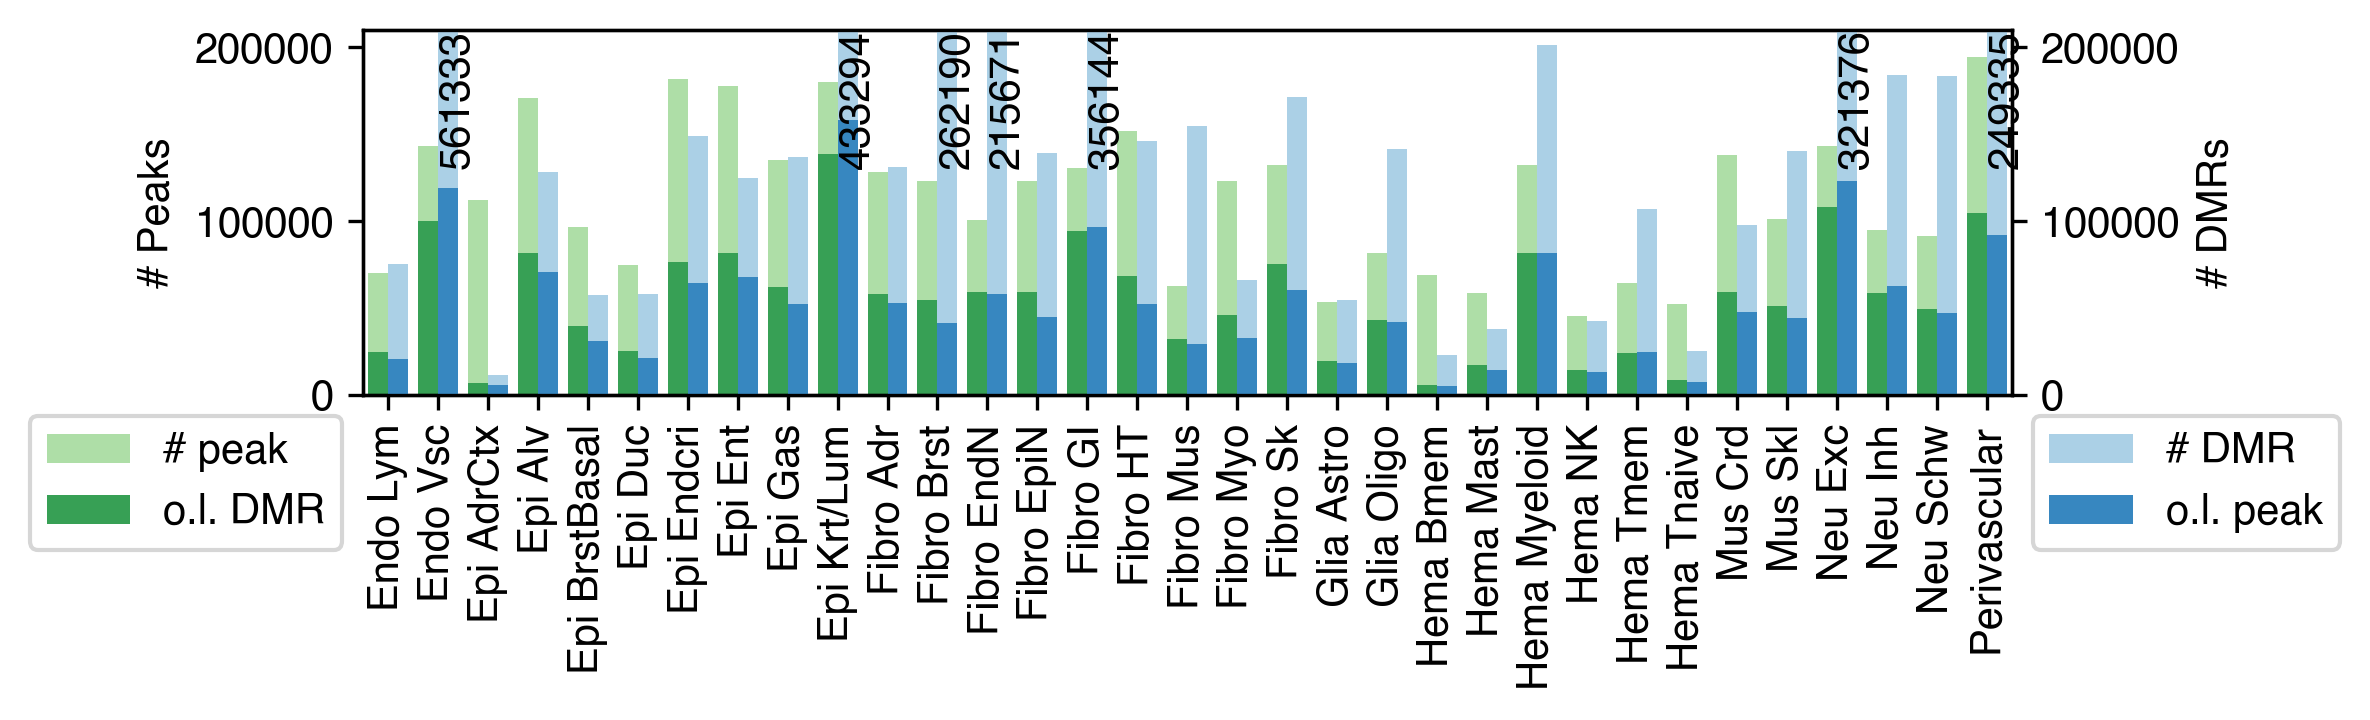

In [15]:
ngroup = 36
out_dir = f'{indir}analysis/DMR/overlap_atac/majortype_{ngroup}groups/'
ndms = 4
data1 = pd.read_csv(f'{out_dir}/dms{ndms}_merged_atac_count_new.txt', sep=' ', header=None, index_col=0)
data1 = data1.loc[L1_meta.index]
data1 = data1.loc[data1[1]>0]

data2 = pd.read_csv(f'{out_dir}/dms{ndms}_merged_dmr_count_new.txt', sep=' ', header=None, index_col=0)
data2 = data2.loc[L1_meta.index]
data2 = data2.loc[data2[1]>0]

selc = data1.index.intersection(data2.index)
data1 = data1.loc[selc]
data2 = data2.loc[selc]
print(pd.concat([data1[1]/data1[2], data2[1]/data2[2]], axis=1).mean(axis=0))

# colors = sns.color_palette('tab20', 4)
colors = list(list(sns.color_palette('Greens_r', 2) + sns.color_palette('Blues_r', 2)))
fig, ax = plt.subplots(figsize=(8, 2.5), dpi=300)
ax.bar(np.arange(data1.shape[0])-0.2, data1[2], color=colors[1], width=0.4, label='# peak')
ax.bar(np.arange(data1.shape[0])-0.2, data1[1], color=colors[0], width=0.4, label='o.l. DMR')
ax.legend(bbox_to_anchor=(0, 0), loc='upper right')

ax2 = ax.twinx()
ax2.bar(np.arange(data2.shape[0])+0.2, np.clip(data2[2], a_min=0, a_max=2.1e5), color=colors[3], width=0.4, label='# DMR')
ax2.bar(np.arange(data2.shape[0])+0.2, data2[1], color=colors[2], width=0.4, label='o.l. peak')
ax2.legend(bbox_to_anchor=(1, 0), loc='upper left')
ax2.set_ylim([0, 210000])
ax.set_ylim([0, 210000])
ax.set_xticks(np.arange(data1.shape[0]))
ax.set_xticklabels(data1.index.map(L1_annot), rotation=90)
ax.set_ylabel('# Peaks')
ax2.set_ylabel('# DMRs')
ax.set_xlim([-0.5, data1.shape[0]-0.5])

for xx,yy in zip(np.where(data2[2]>2.1e5)[0], data2.loc[data2[2]>2.1e5, 2]):
    ax2.text(xx, 2.1e5, yy, rotation=90, va='top')

fig.tight_layout()
fig.savefig('DMR/merged_DMR_ATACpeak_overlap_bar_cap.pdf', transparent=True)


In [16]:
from matplotlib_venn import venn2
colors = list(list(sns.color_palette('Greens_r', 1) + sns.color_palette('Blues_r', 1)))


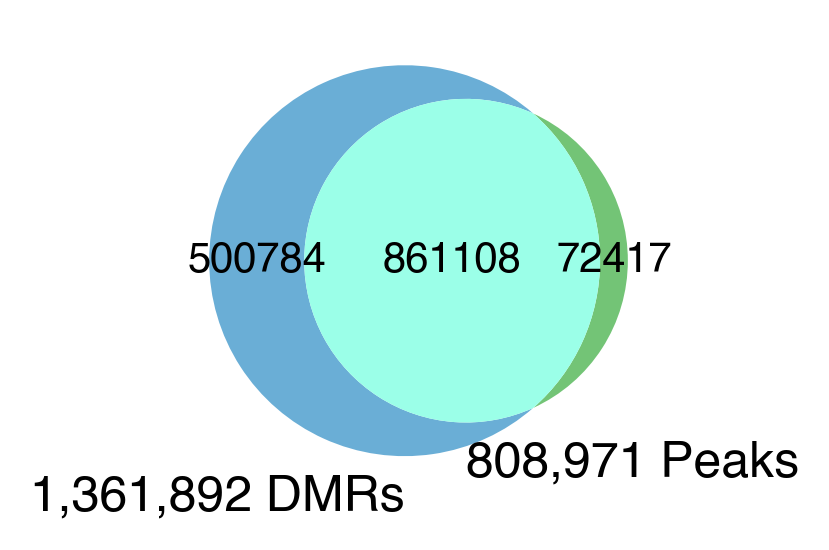

In [17]:
fig, ax = plt.subplots(figsize=(4,2), dpi=300)
venn2(subsets=(1361892-861108, 808971-736554, 861108), 
      set_labels=('1,361,892 DMRs', '808,971 Peaks'),
      alpha=1.0,
      set_colors=(sns.color_palette('Blues', 1)[0], sns.color_palette('Greens', 1)[0]), 
      ax=ax)
fig.savefig(f'{outdir}DMR_ATACpeak_overlap_venn.pdf', transparent=True)


In [18]:
import os

dmr_len = []
dmr_stats = []
for ct in L1_meta.index:
    dmr_file_path = f'{indir}DMR/majortype-subtype/{ct}_dmr/dmr.bed'
    if os.path.isfile(dmr_file_path):
        dmr = pd.read_csv(dmr_file_path, names=['chrom', 'start', 'end', 'dmr_id'], 
                          header=None, index_col=3, sep='\t')
        tmp = pd.DataFrame(dmr['end'] - dmr['start'], columns=['length'])
        tmp['L1'] = ct
        dmr_len.append(tmp)
        dmr_stats.append([ct, tmp.shape[0], tmp['length'].sum()])
    
dmr_len = pd.concat(dmr_len, axis=0)
dmr_stats = pd.DataFrame(dmr_stats, columns=['L1', '#DMR', 'length']).set_index('L1')


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300)
# ax.spines['bottom'].set_position('zero')
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
xticks = np.arange(dmr_stats.shape[0])
for i,xx in enumerate(['#DMR', 'length']):
    ax = axes[i]
    leg_order = dmr_stats.sort_values(xx).index[::-1]
    tmp = dmr_stats.loc[leg_order]
    ax.bar(x=np.arange(dmr_stats.shape[0]), height=tmp[xx], color=tmp.index.map(L1_color), width=0.8)
    ax.set_xticks(xticks)
    ax.set_xticklabels(tmp.index.map(L1_annot), fontsize=6, rotation=90)
    ax.set_yscale('log')
    ax.set_xlim([-1, dmr_stats.shape[0]])
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    
fig.tight_layout()


In [20]:
def expand_bed(input_file, window_size, window, split, min_split_size):

    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    bed = pd.read_csv(input_file, sep='\t', header=None, index_col=None, usecols=[0,1,2], names=['chrom', 'start', 'end'])
    bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]

    if split==0:
        mid = ((bed['start'] + bed['end']) // 2).astype(int)
        bed['start'], bed['end'] = mid.copy(), mid.copy()
    bed['start'] = bed['start'] - dist
    bed['end'] = bed['end'] + dist
    bed = bed.loc[(bed['start']>0) & (bed['end']<bed['chrom'].map(chrom_sizes))]
    
    bed_new = []
    for idx,xx,yy,zz in bed.reset_index().values:
        if split>0:
            split_size = (zz-yy-2*dist) / split
            if split_size<min_split_size:
                continue
        for i in range(window):
            bed_new.append([xx, yy+window_size*i, yy+window_size*(i+1), f'{idx}_{i}'])
        # if (yy+dist)<(zz-dist):
        #     bed_new.append([xx, yy+dist, zz-dist])
        if split>0:
            for i in range(split):
                bed_new.append([xx, yy+dist+split_size*i, yy+dist+split_size*(i+1), f'{idx}_{window+i}'])
        for i in range(window):
            bed_new.append([xx, zz-dist+window_size*i, zz-dist+window_size*(i+1), f'{idx}_{window+split+i}'])

    print(len(bed_new))
    bed_new = pd.DataFrame(bed_new)
    bed_new[[1,2]] = np.around(bed_new[[1,2]], decimals=0).astype(int)
    bed_new.to_csv(input_file.replace('.bed',f'.split{split}.slop{dist_str}b.{ws_str}b.bed'), sep='\t', header=False, index=False)
    return dist_str, ws_str


In [21]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}m'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str
        
def generate_flankmap(peak_group, mc_group, window_size=500, window=50, split=0, min_split_size=1):
    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    # dist_str, ws_str = expand_bed(f'{peak_group}.bed', window_size=window_size, window=window, split=split, min_split_size=min_split_size)
    # time.sleep(3)
    cmd = f'bigWigAverageOverBed {mc_group}.CGN-Merge.frac.bw {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.bed {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.{mc_group.split("/")[-1]}.CHN-both.tsv'
    os.system(cmd)
    return


In [22]:
dmr_list = np.array([f'{ENTEX_ROOT}/analysis/DMR/flank_bed/cCREs_distal2k'])

# bw_list = glob(f'{indir}analysis/PMD_RNA/*/*.frac.bw')
bw_list = glob(f'{indir}merged_allc/L1/CGN/c*.frac.bw')
bw_list = np.sort([xx.replace('.CGN-Merge.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [23]:
cpu = 5
w = 50
split = 0
ws = 50
peak_ct = dmr_list[0]

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    # expand_bed(f'{peak_ct}.bed', window_size=ws, window=w, split=split, min_split_size=1)
    for mc_ct in bw_list:
        future = executor.submit(
            generate_flankmap,
            peak_group=peak_ct,
            mc_group=mc_ct,
            window_size=ws, window=w, split=split, min_split_size=1
        )
        futures[future] = f'{peak_ct.split("/")[-1]}-{mc_ct.split("/")[-1]}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [24]:
def save_hdf(peak_ct, mc_ct, ws, w, split):
    data = pd.read_csv(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.CHN-both.tsv', sep='\t', header=None, index_col=0)
    selr = data.index.str.split('_').str[0].astype(int).unique()
    region_tmp = region.iloc[selr]
    ratio = data[5].values.reshape((-1, 100+split))
    cov = data[2].values.reshape((-1, 100+split))
    del data
    ratio[cov==0] = np.nan
    selr = (region_tmp[5]=='-')
    ratio[selr] = ratio[selr, ::-1]
    ratio = pd.DataFrame(ratio, index=region_tmp.index)
    ratio.to_hdf(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.CGN-Merge.hdf', key='data')
    del ratio
    return


In [25]:
# w = 50
# split = 0
# ws = 50
cpu = 4
# peak_ct = dmr_list[0]
# region = pd.read_csv(f'{peak_ct}.bed', sep='\t', header=None, index_col=None)
# region[5] = '+'

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for xx in bw_list:
        mc_ct = xx.split('/')[-1]
        future = executor.submit(
            save_hdf,
            peak_ct=peak_ct,
            mc_ct=mc_ct,
            ws=ws, 
            w=w, 
            split=split, 
        )
        futures[future] = f'{mc_ct}-{peak_ct.split("/")[-1]}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [26]:
from scipy.sparse import load_npz

peak_dir = f'{indir}analysis/mCH_geneflank/'

atac_ct_list = pd.read_csv(f'{indir}scATAC/celltypes.txt.gz', index_col=0, header=None).index
selct = pd.read_csv(f'{indir}scATAC/peak/peaklist.txt', sep='.', index_col=0, header=None).index
selct = atac_ct_list[atac_ct_list.isin(selct)]
print(selct.shape[0])

atac2mt = pd.read_csv(f'{indir}scATAC/atac2majortype.tsv', sep='\t', header=None, index_col=None)
atac2mt = atac2mt.loc[~atac2mt[1].isna()]
mt2atac = {xx:[] for xx in L1_meta['L1_abbr']}
for xx,yy in atac2mt.values:
    for y in yy.split(','):
        mt2atac[y].append(xx)

selct = pd.Series(np.arange(len(selct)), index=selct)

peak_matrix = load_npz(f'{peak_dir}cCREs_distal2k_104celltype.npz')
ctcre = {}
for ct in L1_meta.index:
    ctname = L1_annot[ct]
    if len(mt2atac[ctname])>0:
        selp = peak_matrix[:, selct.loc[mt2atac[ctname]]].getnnz(axis=1)>0
        ctcre[ct] = pd.Series(selp, index=np.arange(region.shape[0]))


In [27]:
ratio = pd.read_hdf(f'{outdir}flank_bed/cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf', key='data')
ratio.loc[0]

In [28]:
bw_ct = 'c33'
ratio = pd.read_hdf(f'{outdir}flank_bed/cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf', key='data')
# selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
# ratio = ratio.loc[selr]
ratio = ratio.fillna(1)
ave, std = np.nanmean(ratio), np.nanstd(ratio)
ratio = (ratio - ave) / std
ratio = ratio.iloc[np.argsort(np.nanmean(ratio, axis=1))]
selp = ctcre[peak_ct].loc[ratio.index]
tmp = ratio.loc[selp]


In [29]:
split = 0
ws = '2k'
w = '50'

data = []
for i,bw_ct in enumerate(L1_meta.index):
    ratio = pd.read_hdf(f'{outdir}flank_bed/cCREs_distal2k.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf', key='data')
    # selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
    # ratio = ratio.loc[selr]
    # ave, std = np.nanmean(ratio), np.nanstd(ratio)
    # ratio = (ratio - ave) / std
    # ratio = ratio.iloc[np.argsort(np.nanmean(ratio, axis=1))]
    data_tmp = []
    for j,peak_ct in enumerate(ctcre):
        selp = ctcre[peak_ct].loc[ratio.index]
        tmp = ratio.loc[selp]
        tmp = np.nanmean(tmp, axis=0)
        data_tmp.append(tmp)
    data_tmp = pd.DataFrame(data_tmp, index=ctcre.keys())
    data_tmp = (data_tmp - data_tmp.values.min()) / (data_tmp.values.max() - data_tmp.values.min())
    data.append(data_tmp)
    print(bw_ct)
    
data = pd.concat(data, axis=1)
data.columns = np.arange(data.shape[1])
data.to_hdf(f'{outdir}cCREs_distal2k.split{split}.slop{ws}b.{w}b.celltype.hdf', key='data')


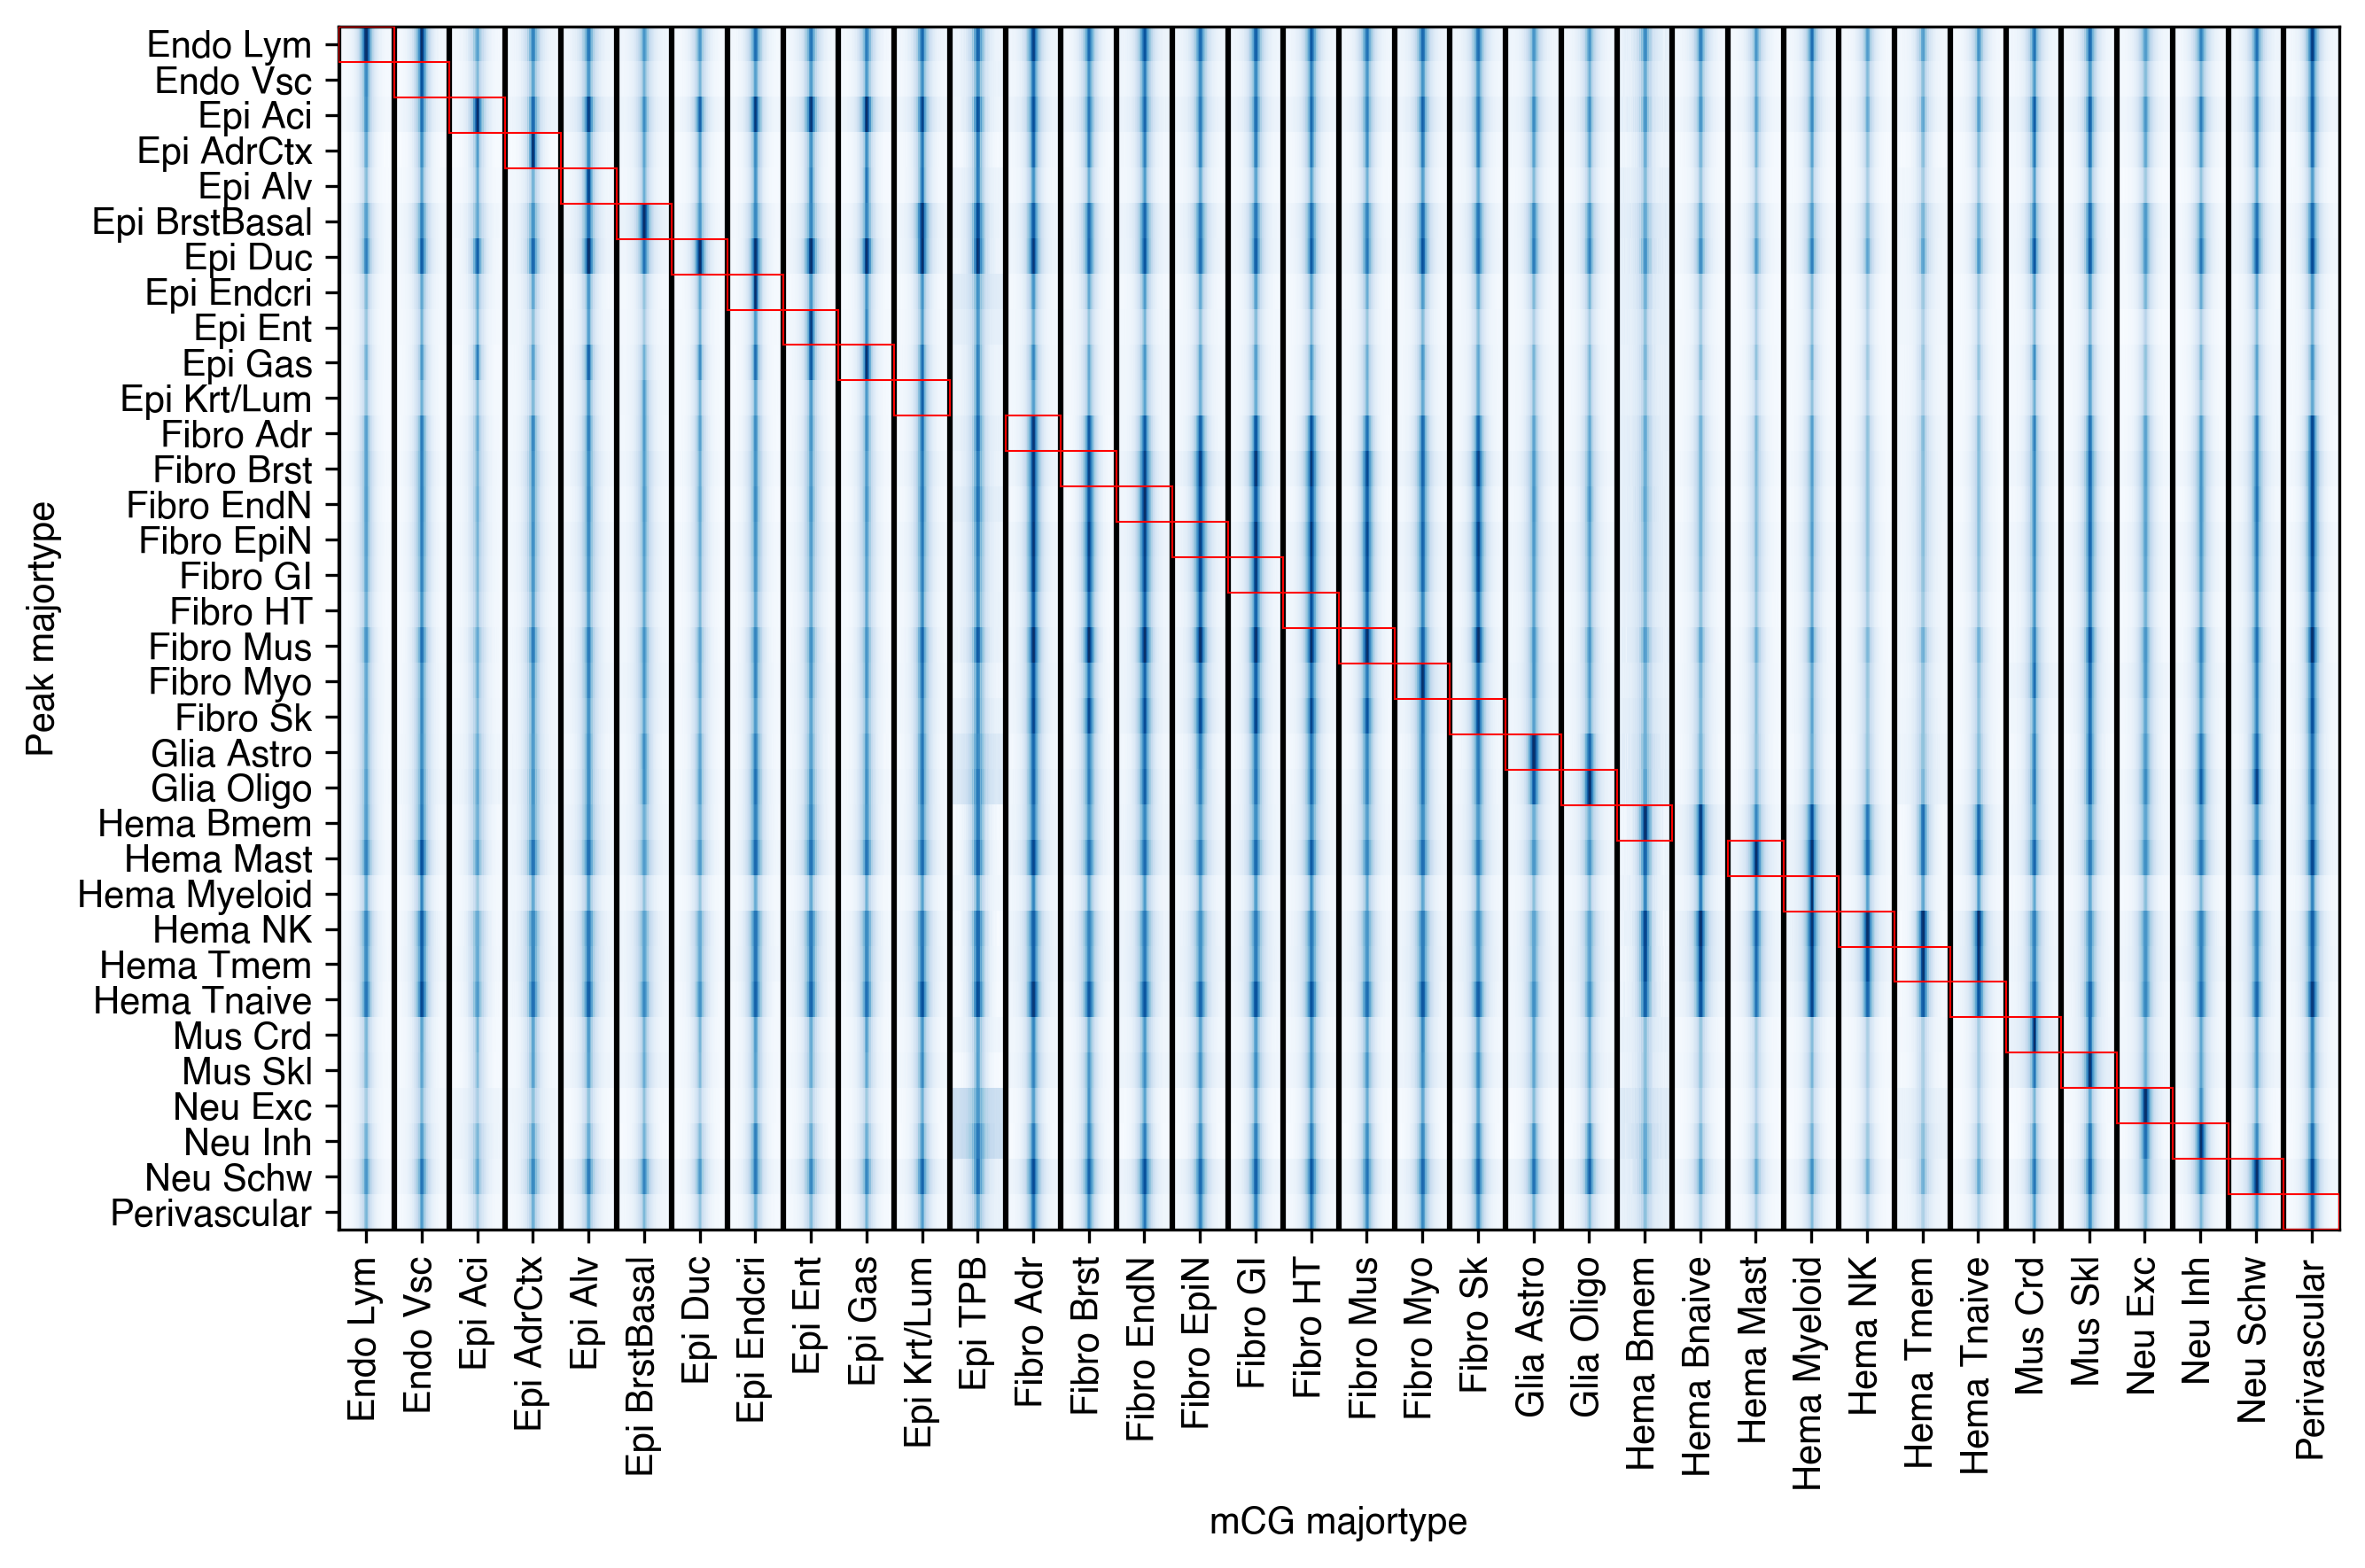

In [30]:
region_idx = pd.Series(np.arange(len(ctcre)), index=ctcre.keys())
color = 'r'
# fig, axes = plt.subplots(1, L1_meta.shape[0], figsize=(12,6), dpi=300, 
#                          gridspec_kw={'wspace':0, 'hspace':0})
bs = int(data.shape[1] // L1_meta.shape[0])
fig, ax = plt.subplots(figsize=(9,6), dpi=300)
ax.imshow(data, cmap='Blues_r', aspect='auto', vmin=0, vmax=1, rasterized=True, interpolation='none')
ax.set_xticks(np.arange(L1_meta.shape[0])*bs+0.5*bs-0.5)
ax.set_xticklabels(L1_meta.index.map(L1_annot), rotation=90)
ax.set_yticks(np.arange(len(ctcre)))
ax.set_yticklabels(pd.Index(ctcre.keys()).map(L1_annot))
for i,bw_ct in enumerate(L1_meta.index):
    xx = bs*i-0.5
    ax.plot([xx, xx], [-0.5, len(ctcre)-0.5], 'k')
    if bw_ct in region_idx.index:
        yy = region_idx.loc[bw_ct]-0.5
        ax.plot([xx, xx], [yy, yy+1], color, linewidth=0.5, zorder=10)
        ax.plot([xx+bs, xx+bs], [yy, yy+1], color, linewidth=0.5, zorder=10)
        ax.plot([xx, xx+bs], [yy, yy], color, linewidth=0.5, zorder=10)
        ax.plot([xx, xx+bs], [yy+1, yy+1], color, linewidth=0.5, zorder=10)
    # data.append(datatmp)

ax.set_xlabel('mCG majortype')
ax.set_ylabel('Peak majortype')

fig.tight_layout()
fig.savefig(f'{outdir}cCREs_distal2k_flankCG.pdf', transparent=True)


In [31]:
mcds = MCDS.open(f'{outdir}overlap_atac/majortype_36groups/subtype_dmr.mcds', obs_dim='subtype', var_dim='DMR')
mcds

In [32]:
black_list_path = '/large_experiments/zhoulab/ref/blacklist/hg38-blacklist.v2.bed.gz'
mcds = mcds.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)


In [33]:
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0).fillna('')
L2_meta['L1'] = L2_meta.index.str.split('-').str[0]
L2_meta.loc[L2_meta['L1']=='c7', 'L1'] = 'c35'
L2_meta.loc[L2_meta.index=='c7-b1'] = 'c36'


In [34]:
mcds = mcds.assign_coords(L1=('subtype', L2_meta.loc[mcds.get_index('subtype'), 'L1']))
mcds = mcds.groupby('L1').sum()


In [35]:
# mcds = mcds.assign_coords(chrom10k=('chrom1k', bin_df['chrom1k']))
# mcds = mcds.sel({'mc_type':'CGN'})
mcds = MCDS(mcds, obs_dim='L1', var_dim='DMR')
mcds

In [36]:
mcds.add_mc_frac(normalize_per_cell=False)
data_all = mcds['DMR_da_frac'].to_pandas()


In [37]:
data_all.to_hdf(f'{outdir}overlap_atac/majortype_36groups/L1_merged_dmr.hdf', key='data')


In [38]:
dmr = mcds[['DMR_chrom', 'DMR_start', 'DMR_end']].to_pandas()
dmr = dmr.reset_index().set_index(['DMR_chrom', 'DMR_start'])


In [39]:
data_all = pd.read_hdf(f'{outdir}overlap_atac/majortype_36groups/L1_merged_dmr.hdf', key='data')
print(data_all.shape)

In [40]:
dmr = dmr.loc[dmr['DMR'].isin(data_all.columns)]

In [41]:
selp = pd.read_csv(f'{outdir}overlap_atac/majortype_36groups/merged_dmr_nonpeak.bed', 
                   header=None, index_col=None, sep='\t', names=['chrom', 'start', 'end'])
selp = selp.set_index(['chrom', 'start'])
selp = selp[selp.index.isin(dmr.index)]
selp = dmr.loc[selp.index, 'DMR'].values
print(len(selp))


In [42]:
from sklearn.metrics import pairwise_distances
data = data_all.loc[:, selp].drop('c2', axis=0)
dist = pairwise_distances(data, data, metric='correlation')
dist = pd.DataFrame(dist, index=data.index, columns=data.index)
dist1 = dist.copy()

In [43]:
from ALLCools.clustering import *
cpu = 32
nboot = 10000
method_dist = 'correlation'
method_hclust = 'average'

dendro = Dendrogram(nboot=nboot,
                    method_dist=method_dist,
                    method_hclust=method_hclust,
                    n_jobs=32)
dendro.fit(dist)


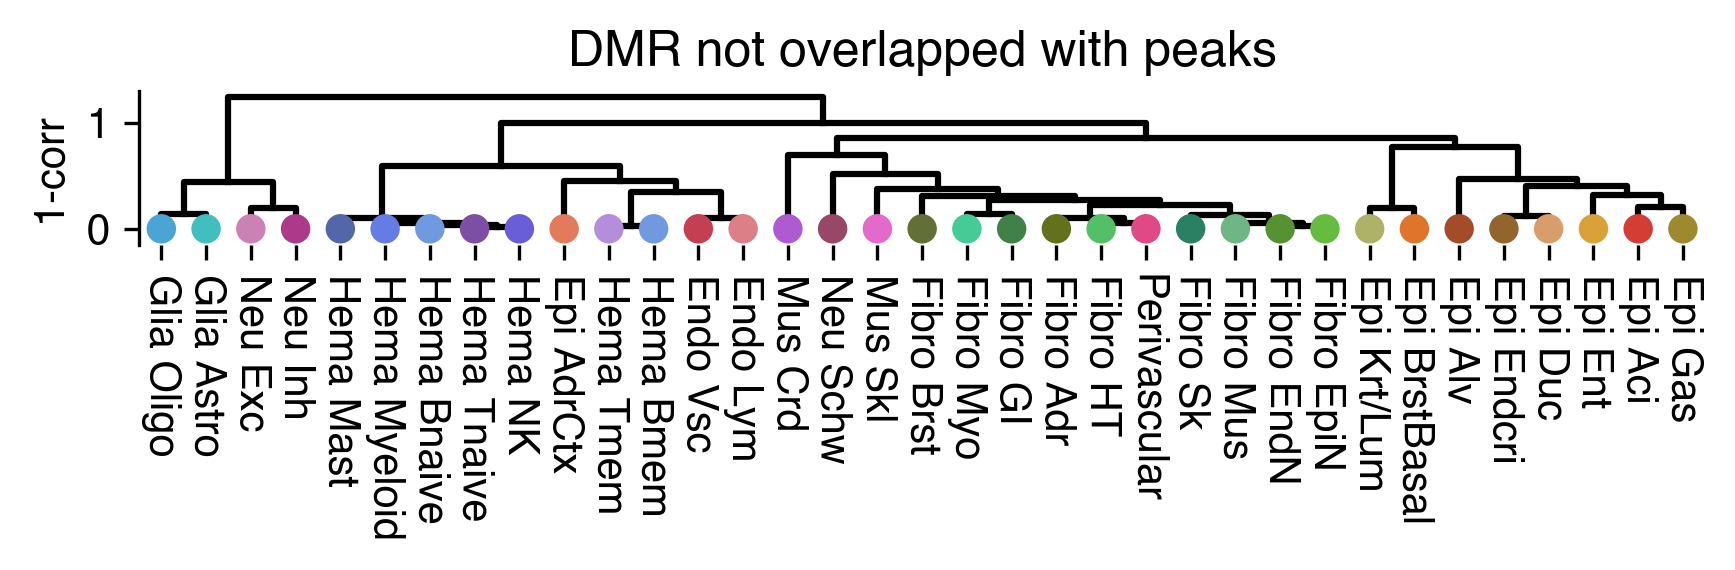

In [44]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
nc = dist.shape[0]
for xx,yy in zip(dendro.dendrogram['icoord'], dendro.dendrogram['dcoord']):
    ax.plot(xx, yy, color='k')

ax.scatter(np.arange(nc)*10+5, np.zeros(nc), s=50, c=L1_meta.loc[dendro.dendrogram['ivl'], 'color'], 
           edgecolor='none', zorder=100, rasterized=True)
ax.set_xticks(np.arange(nc)*10+5)
ax.set_xticklabels(L1_meta.loc[dendro.dendrogram['ivl'], 'L1_abbr'], 
                   rotation=270)

ax.set_xlim([0, nc*10])
ax.set_ylim([-0.15, 1.3])
sns.despine(ax=ax, top=True, right=True, left=False, bottom=True)
ax.set_ylabel('1-corr')
ax.set_title('DMR not overlapped with peaks')
fig.tight_layout()
fig.savefig(f'DMR/dendrogram_majortype_nonpeakdmr.pdf', transparent=True)


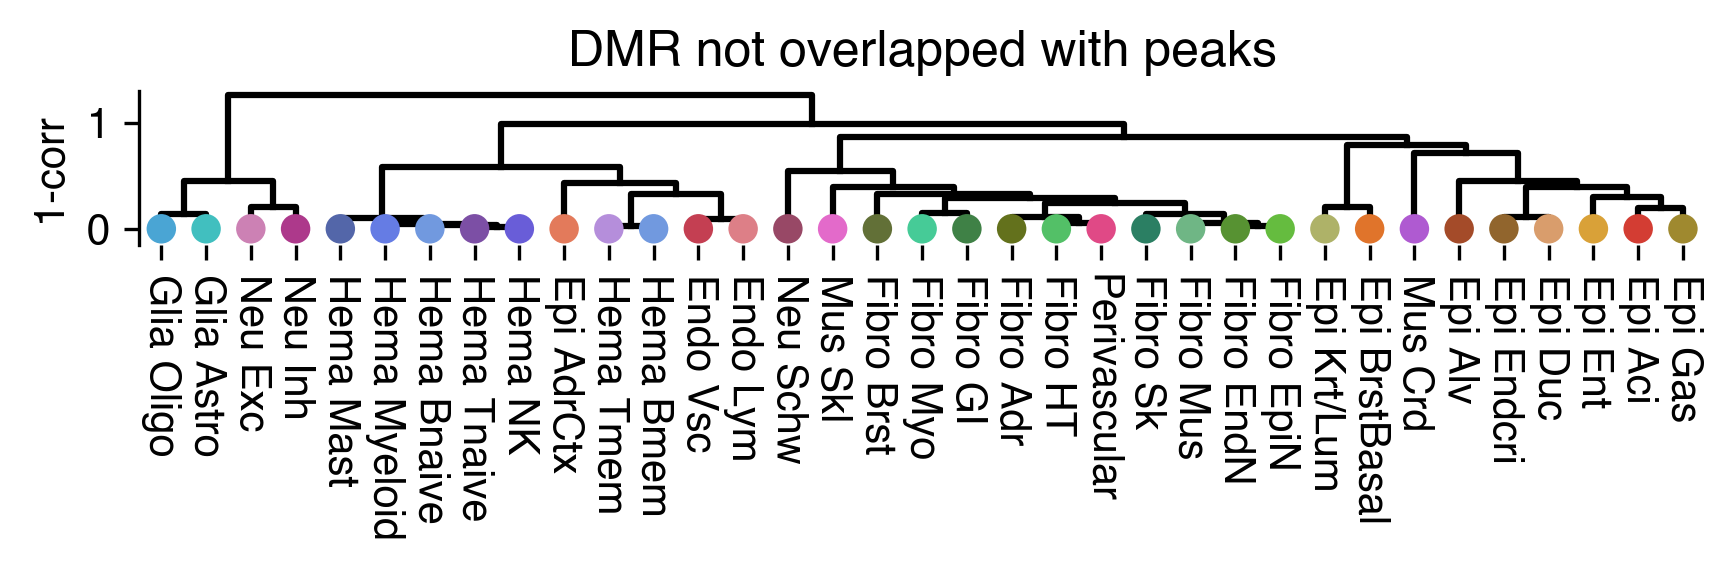

In [45]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
nc = dist.shape[0]
for xx,yy in zip(dendro.dendrogram['icoord'], dendro.dendrogram['dcoord']):
    ax.plot(xx, yy, color='k')

ax.scatter(np.arange(nc)*10+5, np.zeros(nc), s=50, c=L1_meta.loc[dendro.dendrogram['ivl'], 'color'], 
           edgecolor='none', zorder=100, rasterized=True)
ax.set_xticks(np.arange(nc)*10+5)
ax.set_xticklabels(L1_meta.loc[dendro.dendrogram['ivl'], 'L1_abbr'], 
                   rotation=270)

ax.set_xlim([0, nc*10])
ax.set_ylim([-0.15, 1.3])
sns.despine(ax=ax, top=True, right=True, left=False, bottom=True)
ax.set_ylabel('1-corr')
ax.set_title('DMR not overlapped with peaks')
fig.tight_layout()
fig.savefig(f'DMR/dendrogram_majortype_nonpeakdmr.pdf', transparent=True)


In [46]:
selp = pd.read_csv(f'{outdir}overlap_atac/majortype_36groups/merged_dmr_peak.bed', 
                   header=None, index_col=None, sep='\t', names=['chrom', 'start', 'end'])
selp = selp.set_index(['chrom', 'start'])
selp = selp[selp.index.isin(dmr.index)]
selp = dmr.loc[selp.index, 'DMR'].values
print(len(selp))

In [47]:
from sklearn.metrics import pairwise_distances
data = data_all.loc[:, selp].drop('c2', axis=0)
dist = pairwise_distances(data, data, metric='correlation')
dist = pd.DataFrame(dist, index=data.index, columns=data.index)
dist2 = dist.copy()

In [48]:
from ALLCools.clustering import *
cpu = 32
nboot = 10000
method_dist = 'correlation'
method_hclust = 'average'

dendro = Dendrogram(nboot=nboot,
                    method_dist=method_dist,
                    method_hclust=method_hclust,
                    n_jobs=32)
dendro.fit(dist)


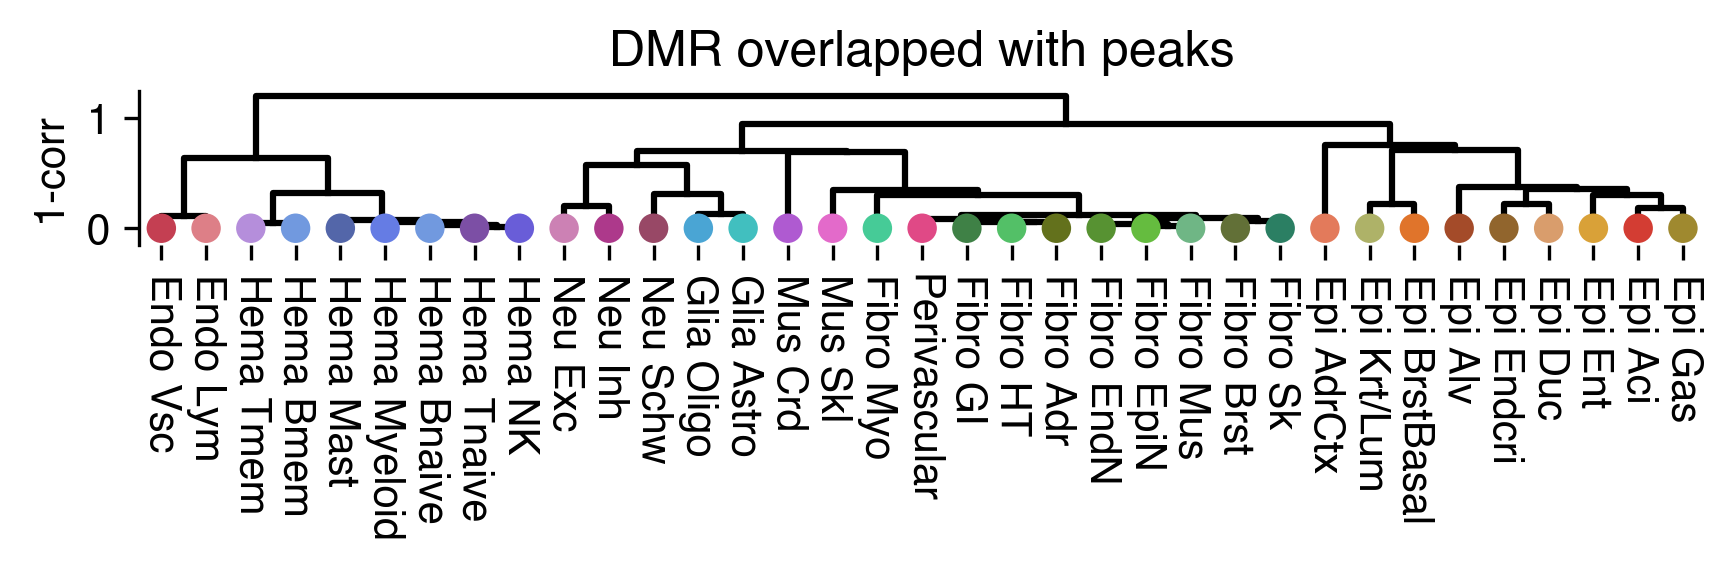

In [49]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
nc = dist.shape[0]
for xx,yy in zip(dendro.dendrogram['icoord'], dendro.dendrogram['dcoord']):
    ax.plot(xx, yy, color='k')

ax.scatter(np.arange(nc)*10+5, np.zeros(nc), s=50, c=L1_meta.loc[dendro.dendrogram['ivl'], 'color'], 
           edgecolor='none', zorder=100, rasterized=True)
ax.set_xticks(np.arange(nc)*10+5)
ax.set_xticklabels(L1_meta.loc[dendro.dendrogram['ivl'], 'L1_abbr'], 
                   rotation=270)

ax.set_xlim([0, nc*10])
ax.set_ylim([-0.15, 1.25])
sns.despine(ax=ax, top=True, right=True, left=False, bottom=True)
ax.set_ylabel('1-corr')
ax.set_title('DMR overlapped with peaks')
fig.tight_layout()
fig.savefig(f'DMR/dendrogram_majortype_peakdmr.pdf', transparent=True)


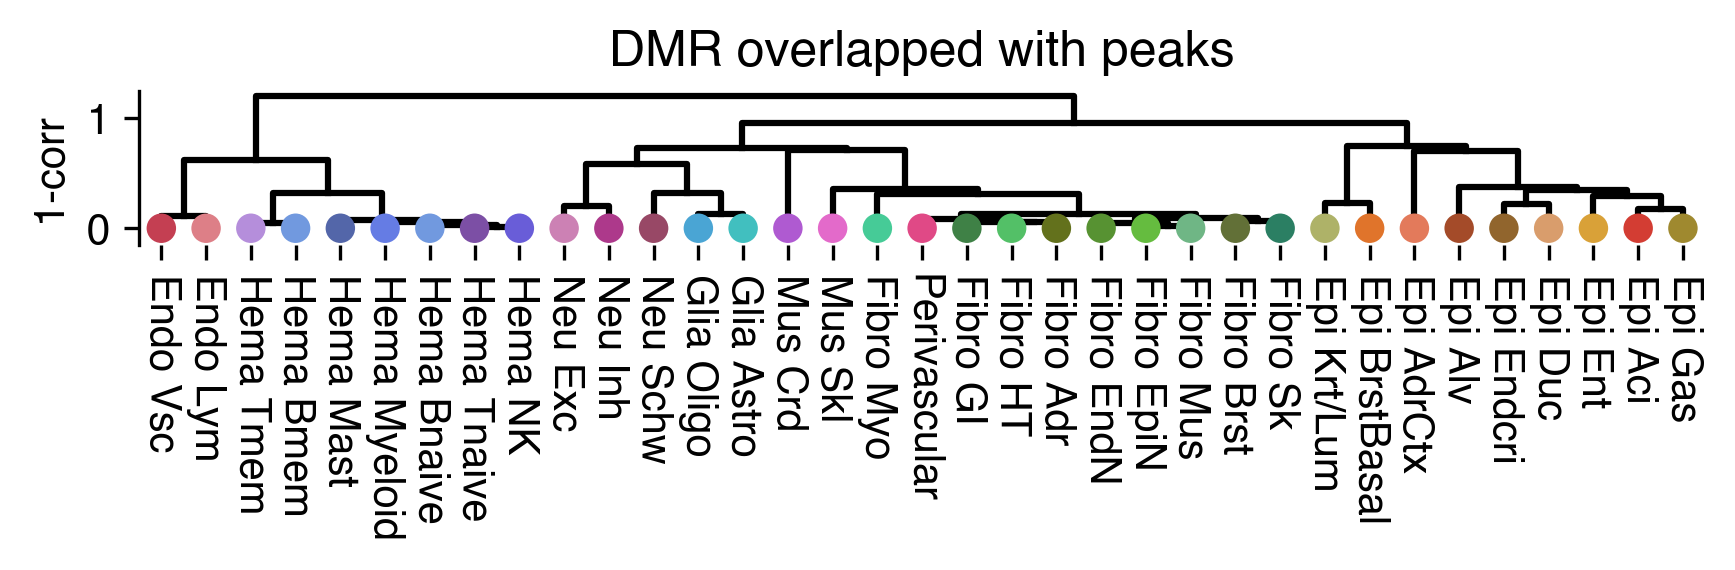

In [50]:
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
nc = dist.shape[0]
for xx,yy in zip(dendro.dendrogram['icoord'], dendro.dendrogram['dcoord']):
    ax.plot(xx, yy, color='k')

ax.scatter(np.arange(nc)*10+5, np.zeros(nc), s=50, c=L1_meta.loc[dendro.dendrogram['ivl'], 'color'], 
           edgecolor='none', zorder=100, rasterized=True)
ax.set_xticks(np.arange(nc)*10+5)
ax.set_xticklabels(L1_meta.loc[dendro.dendrogram['ivl'], 'L1_abbr'], 
                   rotation=270)

ax.set_xlim([0, nc*10])
ax.set_ylim([-0.15, 1.25])
sns.despine(ax=ax, top=True, right=True, left=False, bottom=True)
ax.set_ylabel('1-corr')
ax.set_title('DMR overlapped with peaks')
fig.tight_layout()
fig.savefig(f'DMR/dendrogram_majortype_peakdmr.pdf', transparent=True)


In [51]:
cg = sns.clustermap(dist, metric='cosine', cmap='cividis', # vmax=0.05, 
                    xticklabels=data.index.map(L1_annot), yticklabels=data.index.map(L1_annot),)
rorder = dist.index[cg.dendrogram_row.reordered_ind]
corder = dist.columns[cg.dendrogram_col.reordered_ind]


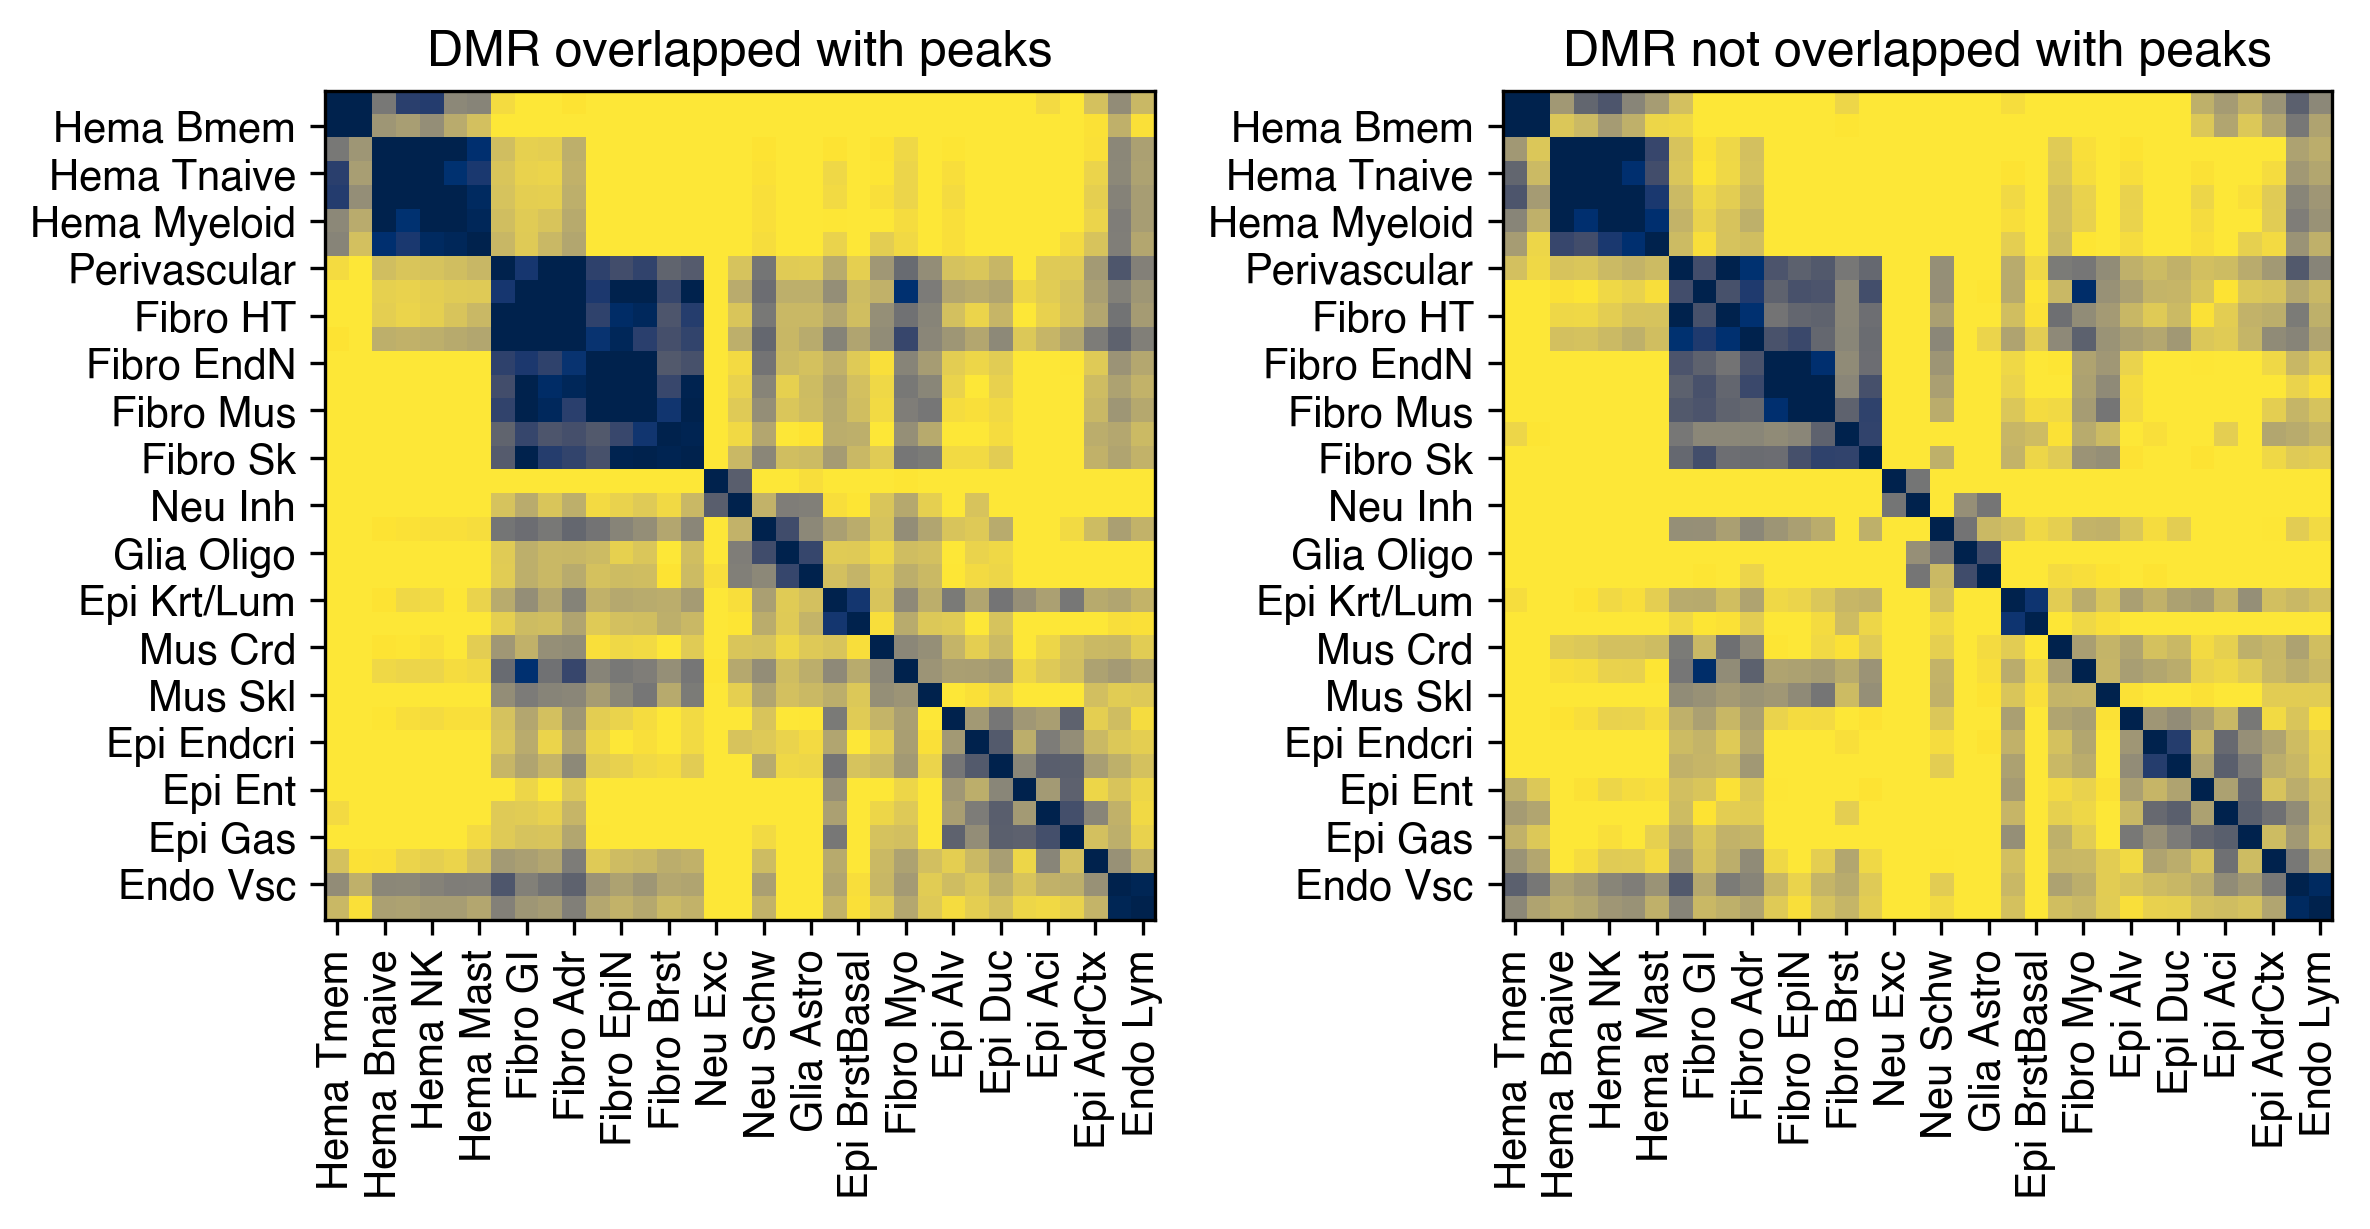

In [52]:
vmin, vmax = 0.2, 0.6
xticks = np.arange(0, dist.shape[0], 2)
yticks = np.arange(1, dist.shape[0], 2)
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)
for i,dist in enumerate([dist2, dist1]):
    ax = axes[i]
    ax.imshow(dist.loc[rorder, corder], cmap='cividis', vmin=vmin, vmax=vmax)
    ax.set_xticks(xticks)
    ax.set_xticklabels(corder.map(L1_annot)[xticks], rotation=90)
    ax.set_yticks(yticks)
    ax.set_yticklabels(rorder.map(L1_annot)[yticks])
    ax.set_title(['DMR overlapped with peaks', 'DMR not overlapped with peaks'][i])

fig.tight_layout()
fig.savefig(f'DMR/L1_peakdmr_nonpeakdmr_corr.pdf', transparent=True)


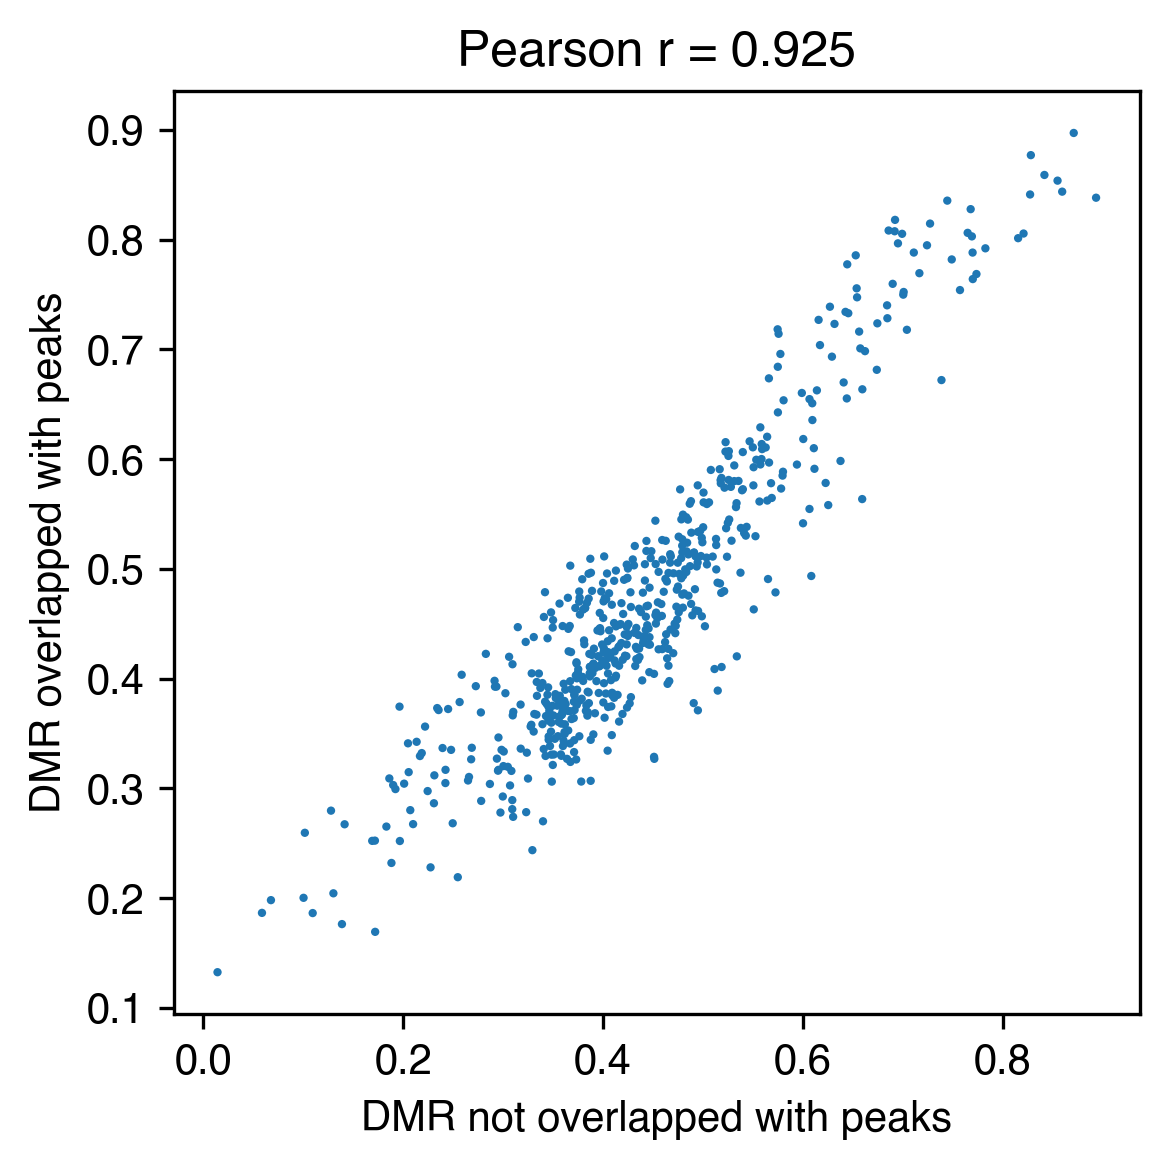

In [53]:
from scipy.stats import pearsonr

fig, ax = plt.subplots(figsize=(4,4), dpi=300)
upper_indices = np.triu_indices(dist.shape[0], k=1)
ax.scatter(x=1-dist1.values[upper_indices], 
           y=1-dist2.values[upper_indices], 
           s=4, edgecolors='none')
ax.set_xlabel('DMR not overlapped with peaks')
ax.set_ylabel('DMR overlapped with peaks')
ax.set_title('Pearson r = {:.3f}'.format(
    pearsonr(1-dist1.values[upper_indices], 1-dist2.values[upper_indices])[0]
))
fig.tight_layout()
fig.savefig(f'DMR/L1_peakdmr_nonpeakdmr_corr_scatter.pdf', transparent=True)
